#  Analyse Exploratoire — Potabilité de l'Eau

Ce notebook couvre :
1. Chargement et inspection initiale des données
2. Pré-traitement (valeurs manquantes, types, doublons)
3. Analyse univariée (distributions, statistiques descriptives)
4. Analyse bivariée (corrélations, potabilité vs variables)
5. Conclusions et recommandations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Style global
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

COLORS = {'potable': '#2196F3', 'non_potable': '#F44336', 'missing': '#FF9800'}
print('Imports OK')

Imports OK


---
## 1. Chargement et Inspection Initiale

In [2]:
df = pd.read_csv('water_potability.csv')

print(f'Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Mémoire    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
df.head()

Dimensions : 3276 lignes × 10 colonnes
Mémoire    : 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
# Description des variables
descriptions = {
    'ph'              : 'pH de l\'eau (OMS : 6.5–8.5)',
    'Hardness'        : 'Dureté (mg/L) — teneur en calcium/magnésium',
    'Solids'          : 'Solides dissous totaux (ppm)',
    'Chloramines'     : 'Chloramines (ppm) — désinfectant',
    'Sulfate'         : 'Sulfates (mg/L)',
    'Conductivity'    : 'Conductivité électrique (μS/cm)',
    'Organic_carbon'  : 'Carbone organique total (ppm)',
    'Trihalomethanes' : 'Trihalométhanes (μg/L) — sous-produits chloration',
    'Turbidity'       : 'Turbidité (NTU) — clarté',
    'Potability'      : 'Cible : 1 = potable, 0 = non potable'
}
desc_df = pd.DataFrame.from_dict(descriptions, orient='index', columns=['Description'])
desc_df.index.name = 'Variable'
desc_df

,Description
Variable,
ph,pH de l'eau (OMS : 6.5–8.5)
Hardness,Dureté (mg/L) — teneur en calcium/magnésium
Solids,Solides dissous totaux (ppm)
Chloramines,Chloramines (ppm) — désinfectant
Sulfate,Sulfates (mg/L)
Conductivity,Conductivité électrique (μS/cm)
Organic_carbon,Carbone organique total (ppm)
Trihalomethanes,Trihalométhanes (μg/L) — sous-produits chloration
Turbidity,Turbidité (NTU) — clarté


In [4]:
print('=== Types & Valeurs manquantes ===')
info = pd.DataFrame({
    'Type'      : df.dtypes,
    'Manquants' : df.isnull().sum(),
    '% Manq.'   : (df.isnull().mean() * 100).round(2),
    'Uniques'   : df.nunique()
})
info

=== Types & Valeurs manquantes ===


,Type,Manquants,% Manq.,Uniques
ph,float64,491,14.99,2785
Hardness,float64,0,0.00,3276
Solids,float64,0,0.00,3276
Chloramines,float64,0,0.00,3276
Sulfate,float64,781,23.84,2495
Conductivity,float64,0,0.00,3276
Organic_carbon,float64,0,0.00,3276
Trihalomethanes,float64,162,4.95,3114
Turbidity,float64,0,0.00,3276
Potability,int64,0,0.00,2


---
## 2. Pré-traitement

Doublons : 0


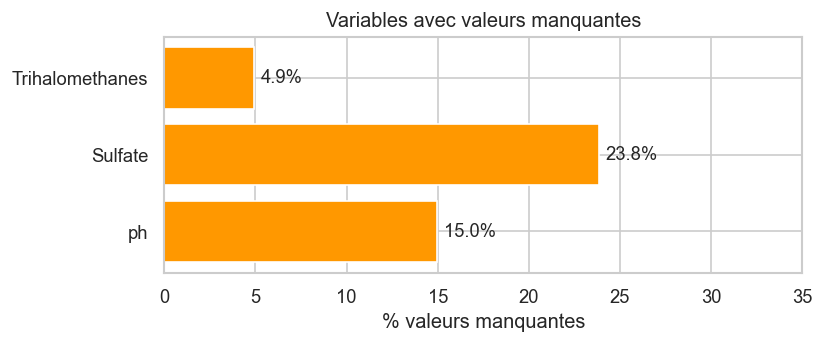

In [5]:
# --- 2.1 Doublons ---
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup}')
if n_dup > 0:
    df = df.drop_duplicates()
    print(f'  → {n_dup} lignes supprimées')

# --- 2.2 Visualisation des valeurs manquantes ---
missing_cols = ['ph', 'Sulfate', 'Trihalomethanes']
miss_pct = df[missing_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(miss_pct.index, miss_pct.values, color=COLORS['missing'], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlabel('% valeurs manquantes')
ax.set_title('Variables avec valeurs manquantes')
ax.set_xlim(0, 35)
plt.tight_layout()
plt.show()

In [6]:
# --- 2.3 Imputation par médiane conditionnelle (par groupe Potabilité) ---
df_clean = df.copy()

for col in missing_cols:
    medians = df_clean.groupby('Potability')[col].transform('median')
    global_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(medians).fillna(global_median)
    print(f'{col:20s} → imputé (médiane par groupe). Restants : {df_clean[col].isnull().sum()}')

print(f'\nDataset final : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')
print(f'Valeurs manquantes totales : {df_clean.isnull().sum().sum()}')

ph                   → imputé (médiane par groupe). Restants : 0
Sulfate              → imputé (médiane par groupe). Restants : 0
Trihalomethanes      → imputé (médiane par groupe). Restants : 0

Dataset final : 3276 lignes × 10 colonnes
Valeurs manquantes totales : 0


In [7]:
# --- 2.4 Détection des valeurs aberrantes (IQR) ---
features = [c for c in df_clean.columns if c != 'Potability']

outlier_report = []
for col in features:
    Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    outlier_report.append({'Variable': col, 'Outliers (IQR)': n_out,
                           '% Outliers': round(n_out / len(df_clean) * 100, 2)})

pd.DataFrame(outlier_report).set_index('Variable')

,Outliers (IQR),% Outliers
Variable,,
ph,142,4.33
Hardness,83,2.53
Solids,47,1.43
Chloramines,61,1.86
Sulfate,264,8.06
Conductivity,11,0.34
Organic_carbon,25,0.76
Trihalomethanes,54,1.65
Turbidity,19,0.58


In [8]:
# --- 2.5 Bornage des outliers extrêmes (Winsorisation 1%-99%) ---
from scipy.stats.mstats import winsorize

df_clean[features] = df_clean[features].apply(
    lambda col: pd.Series(winsorize(col, limits=[0.01, 0.01]), index=col.index)
)
print('Winsorisation appliquée (1%–99%) sur toutes les features')
print('\nStatistiques après pré-traitement :')
df_clean[features].describe().round(2)

Winsorisation appliquée (1%–99%) sur toutes les features

Statistiques après pré-traitement :


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00,3276.00
mean,7.08,196.37,21986.06,7.12,333.59,426.10,14.28,66.43,3.97
std,1.42,32.16,8599.83,1.54,34.94,79.59,3.25,15.40,0.77
min,3.43,113.83,5232.91,3.19,236.00,269.34,6.37,28.40,2.15
25%,6.28,176.85,15666.69,6.13,317.09,365.73,12.07,56.65,3.44
50%,7.04,196.97,20927.83,7.13,333.39,421.88,14.22,66.54,3.96
75%,7.87,216.67,27332.76,8.11,350.39,481.79,16.56,76.67,4.50
max,10.82,278.08,46077.36,11.00,429.05,617.88,22.09,104.68,5.75


---
## 3. Analyse Univariée

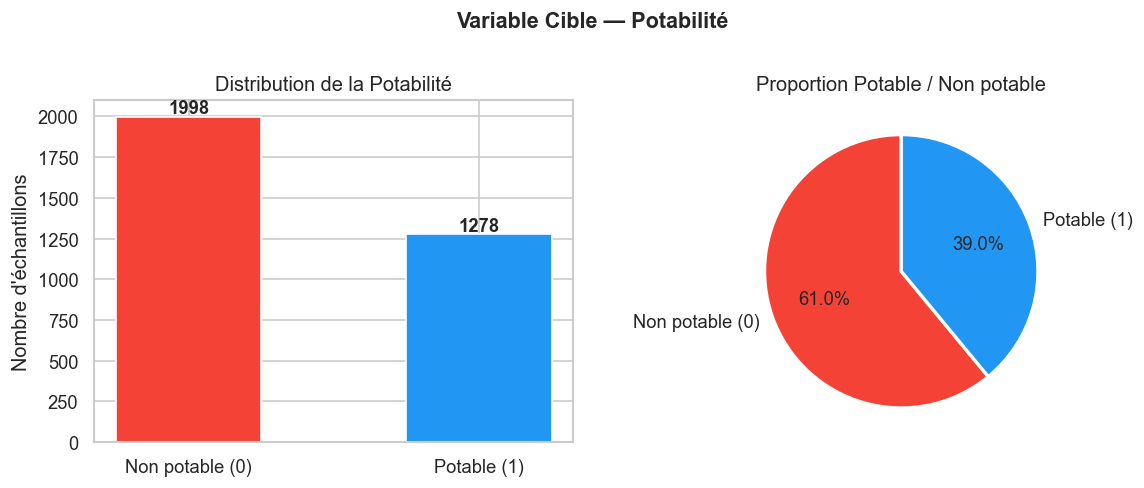

Déséquilibre des classes : ratio 1.56:1 (non potable:potable)


In [9]:
# --- 3.1 Distribution de la variable cible ---
counts = df_clean['Potability'].value_counts()
labels = ['Non potable (0)', 'Potable (1)']
palette = [COLORS['non_potable'], COLORS['potable']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.bar(labels, counts.values, color=palette, edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 20, str(v), ha='center', fontweight='bold')
ax1.set_title('Distribution de la Potabilité')
ax1.set_ylabel('Nombre d\'échantillons')

ax2.pie(counts.values, labels=labels, colors=palette, autopct='%1.1f%%',
        startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proportion Potable / Non potable')

plt.suptitle('Variable Cible — Potabilité', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Déséquilibre des classes : ratio {counts[0]/counts[1]:.2f}:1 (non potable:potable)')

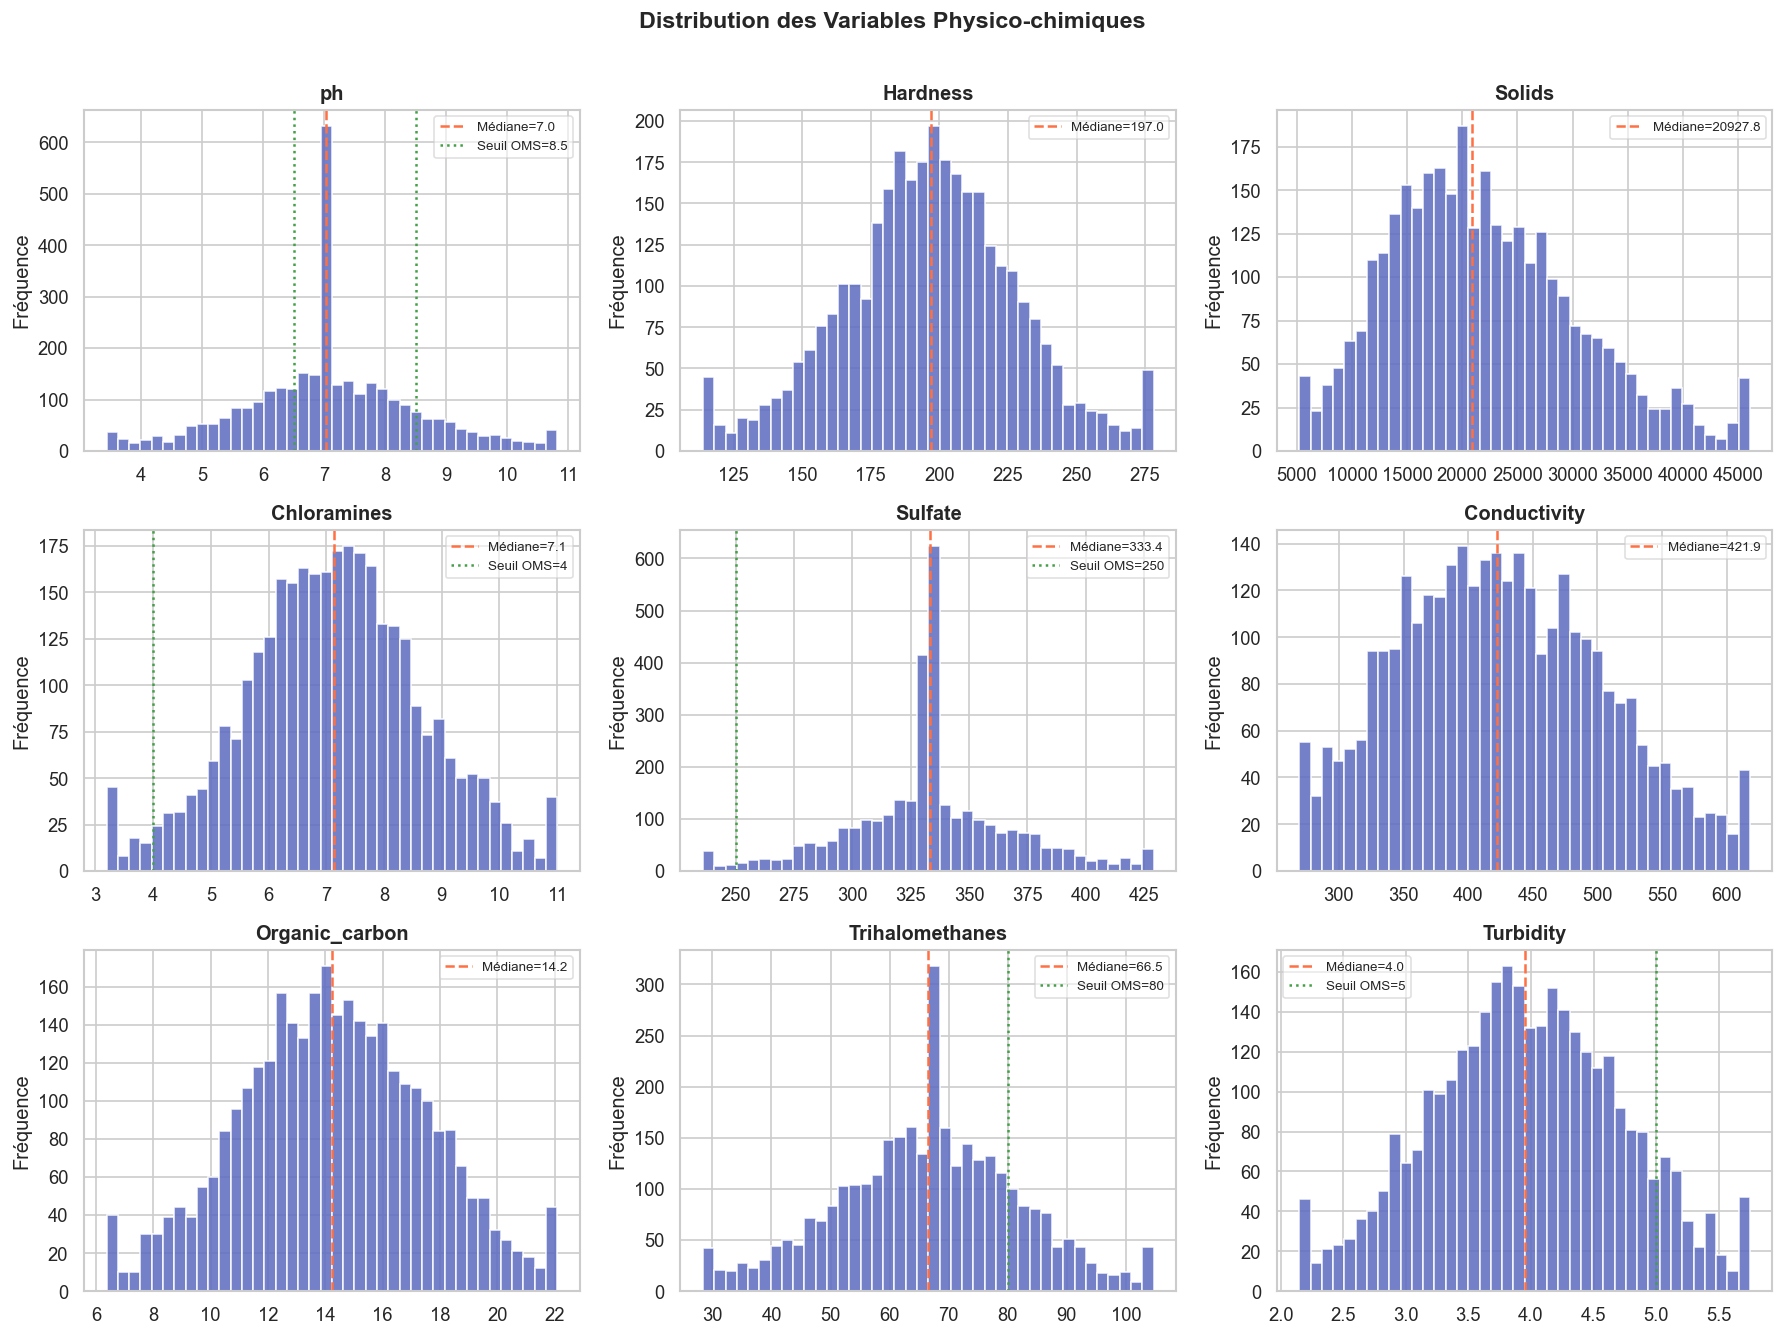

In [10]:
# --- 3.2 Distributions de toutes les features ---
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

# Normes OMS indicatives
norms = {'ph': (6.5, 8.5), 'Chloramines': (None, 4), 'Sulfate': (None, 250),
         'Trihalomethanes': (None, 80), 'Turbidity': (None, 5)}

for i, col in enumerate(features):
    ax = axes[i]
    ax.hist(df_clean[col], bins=40, color='#5C6BC0', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Fréquence')

    # Ligne médiane
    med = df_clean[col].median()
    ax.axvline(med, color='#FF7043', linestyle='--', linewidth=1.5, label=f'Médiane={med:.1f}')

    # Seuil OMS si disponible
    if col in norms:
        lo, hi = norms[col]
        if hi: ax.axvline(hi, color='#43A047', linestyle=':', linewidth=1.5, label=f'Seuil OMS={hi}')
        if lo: ax.axvline(lo, color='#43A047', linestyle=':', linewidth=1.5)
    ax.legend(fontsize=8, framealpha=0.6)

plt.suptitle('Distribution des Variables Physico-chimiques', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# --- 3.3 Statistiques descriptives enrichies ---
stats_df = df_clean[features].agg(['mean','median','std','skew','kurt']).T.round(3)
stats_df.columns = ['Moyenne','Médiane','Écart-type','Asymétrie','Kurtosis']
stats_df.index.name = 'Variable'

def style_skew(val):
    color = '#ffcccc' if abs(val) > 1 else '#ccffcc' if abs(val) < 0.5 else '#fff3cc'
    return f'background-color: {color}'

stats_df.style.map(style_skew, subset=['Asymétrie'])

,Moyenne,Médiane,Écart-type,Asymétrie,Kurtosis
Variable,,,,,
ph,7.075000,7.035000,1.418000,0.076000,0.370000
Hardness,196.373000,196.968000,32.159000,-0.034000,0.105000
Solids,21986.055000,20927.834000,8599.827000,0.533000,-0.044000
Chloramines,7.121000,7.130000,1.541000,-0.023000,-0.029000
Sulfate,333.592000,333.389000,34.936000,0.054000,0.808000
Conductivity,426.097000,421.885000,79.592000,0.230000,-0.546000
Organic_carbon,14.283000,14.218000,3.251000,0.005000,-0.302000
Trihalomethanes,66.429000,66.542000,15.401000,-0.053000,-0.070000
Turbidity,3.966000,3.955000,0.766000,-0.017000,-0.368000


---
## 4. Analyse Bivariée

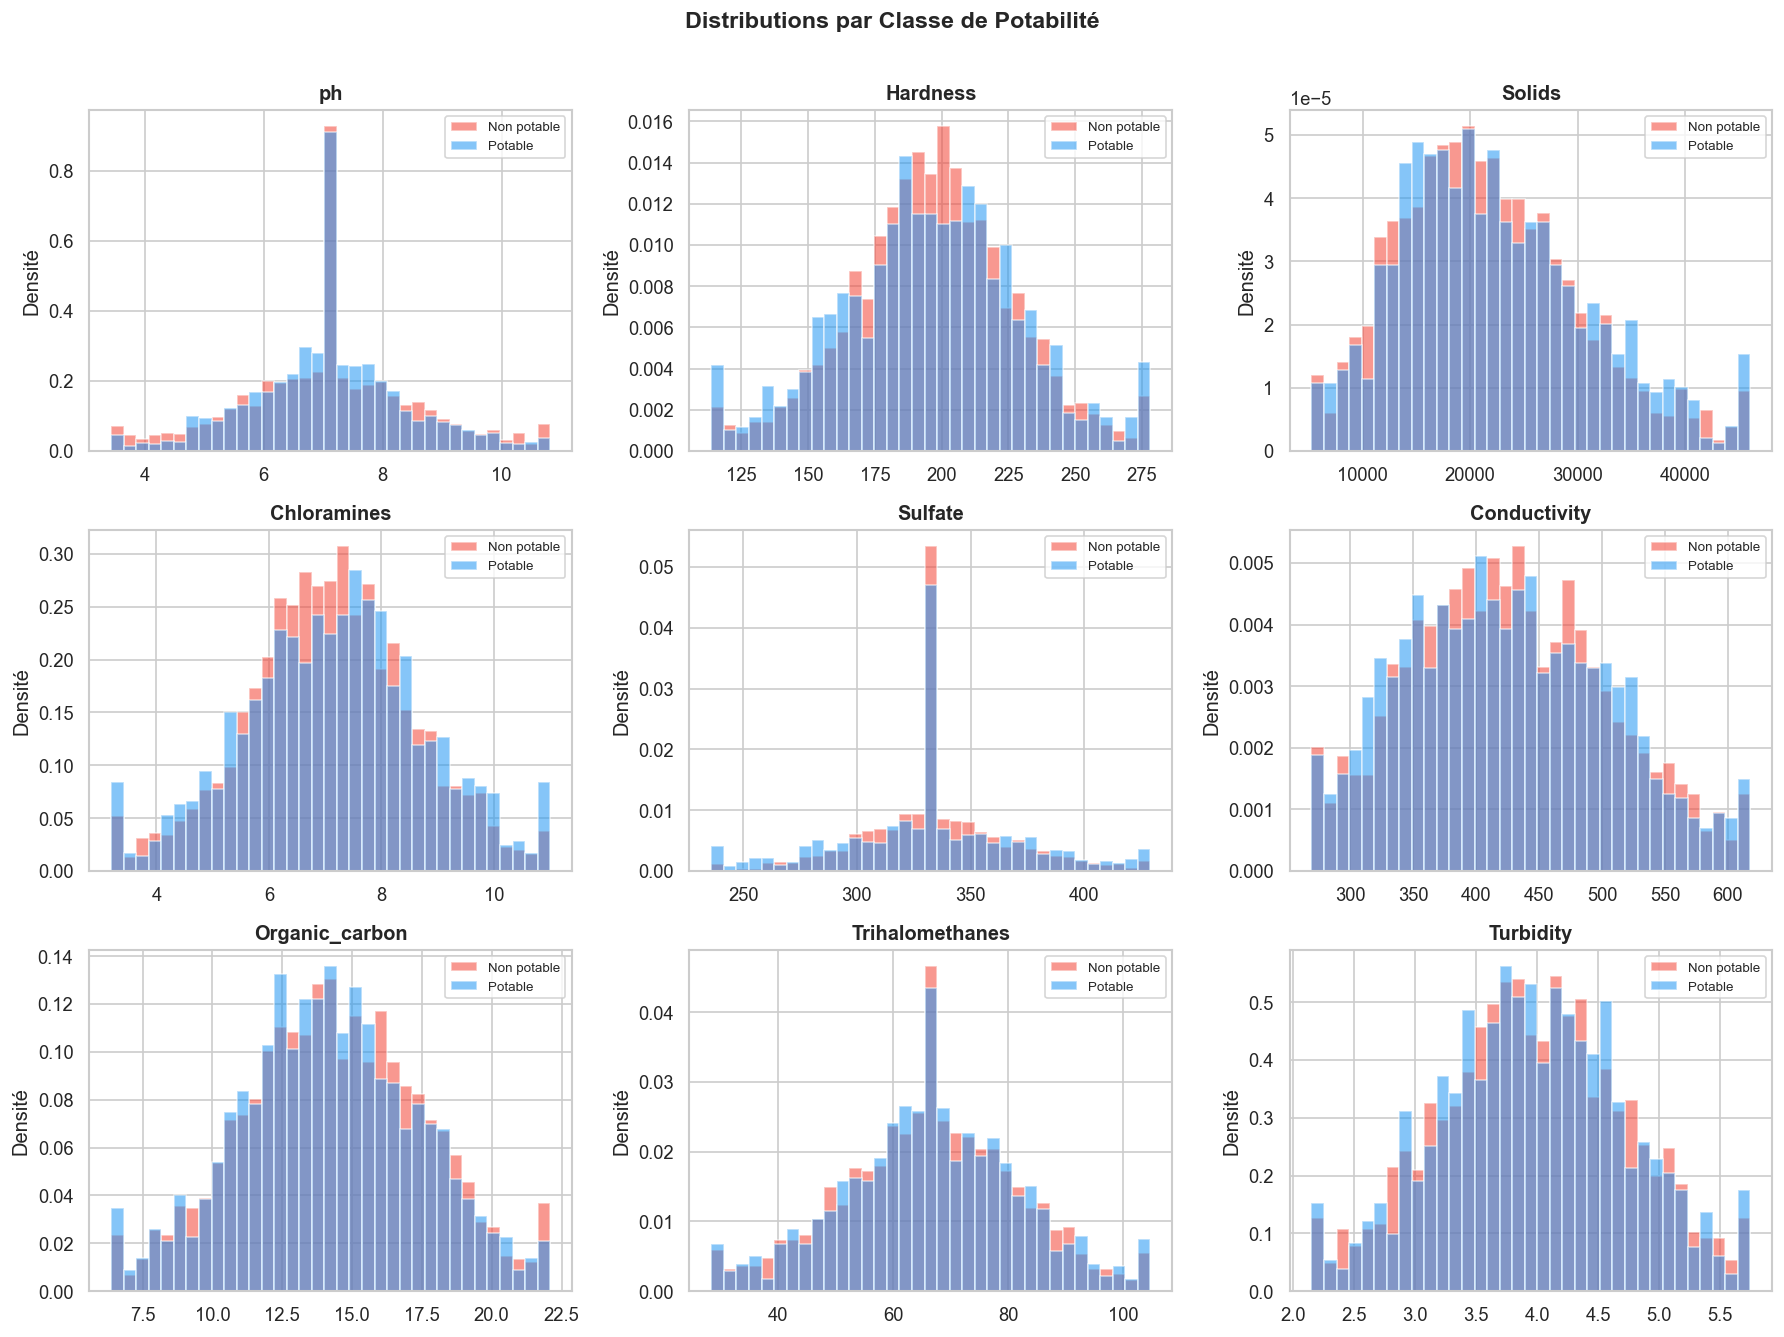

In [12]:
# --- 4.1 Distributions par classe de Potabilité ---
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
palette_bi = {0: COLORS['non_potable'], 1: COLORS['potable']}

for i, col in enumerate(features):
    ax = axes[i]
    for label, color in palette_bi.items():
        subset = df_clean[df_clean['Potability'] == label][col]
        ax.hist(subset, bins=35, alpha=0.55, color=color,
                label='Potable' if label == 1 else 'Non potable', density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)

plt.suptitle('Distributions par Classe de Potabilité', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

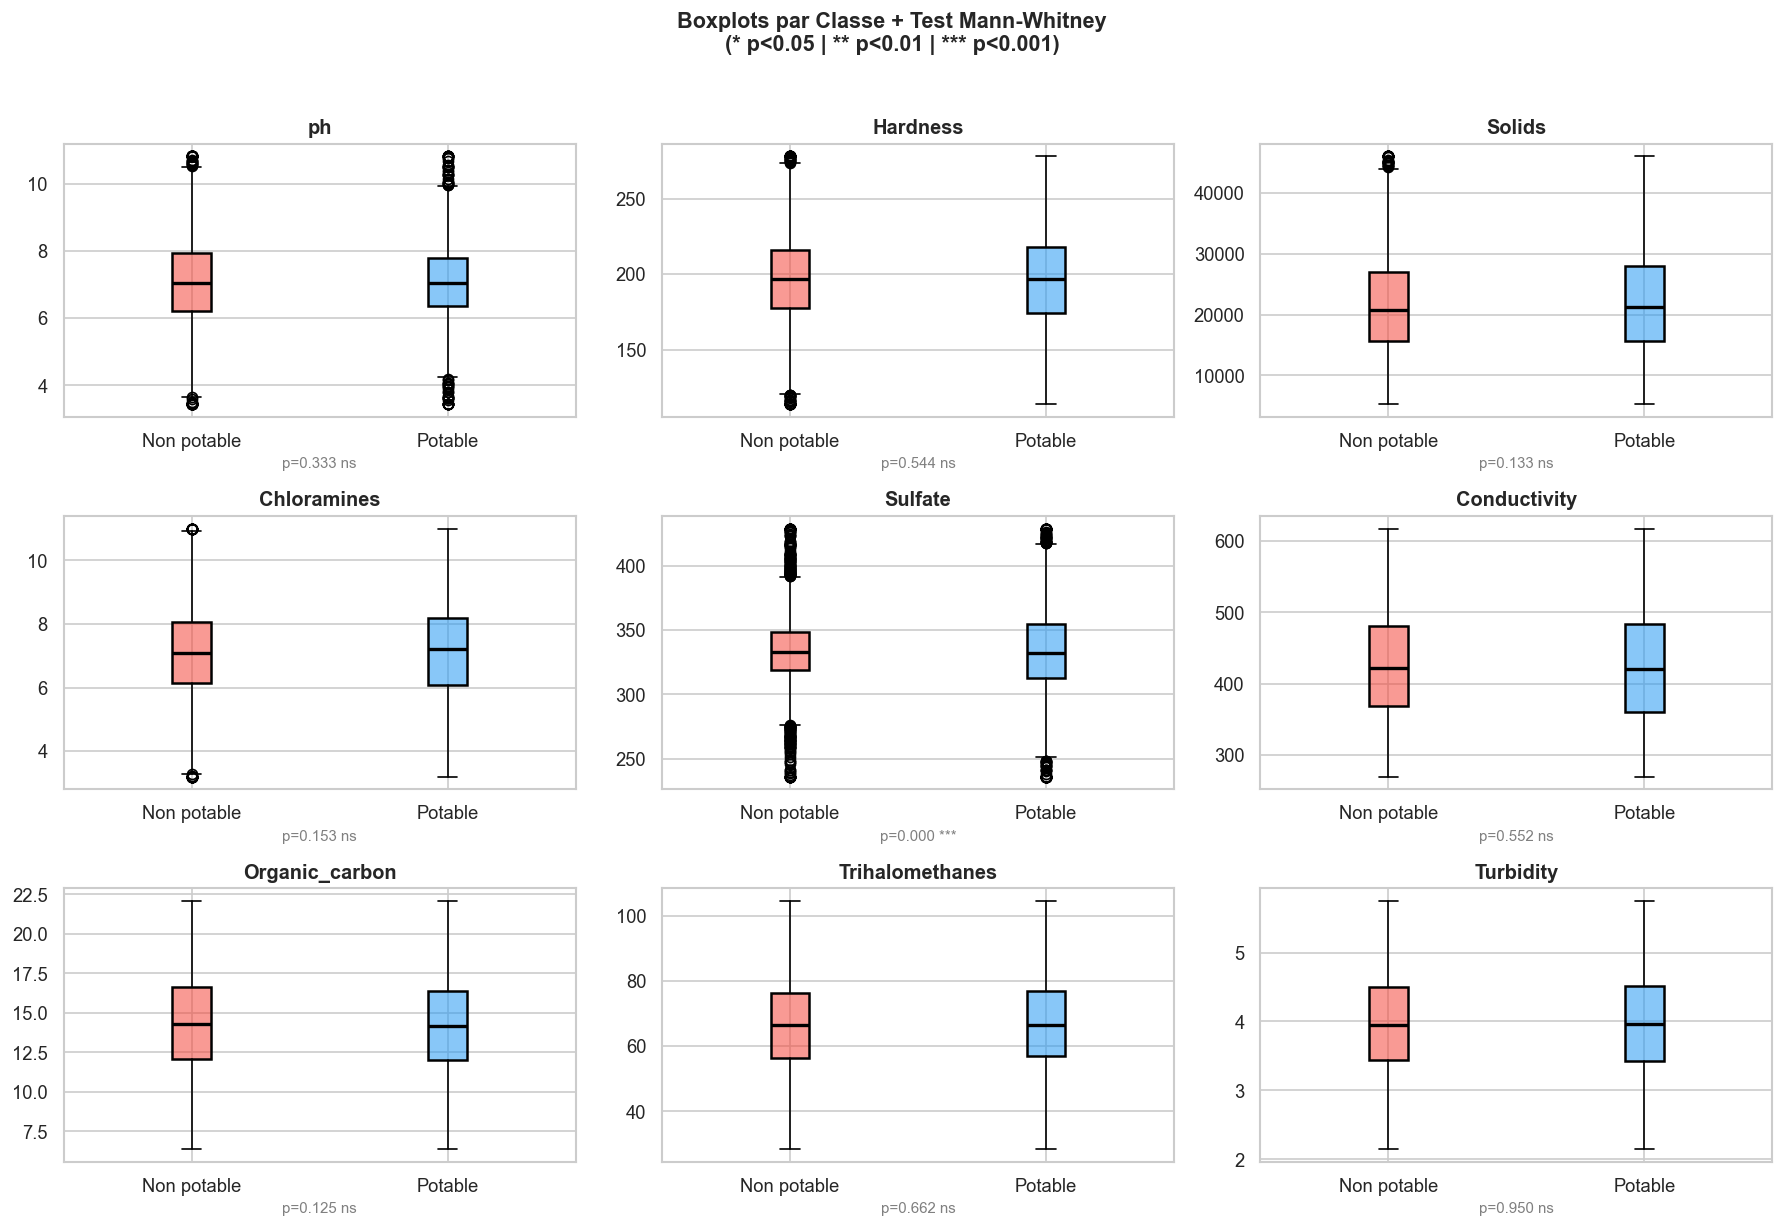

In [13]:
# --- 4.2 Boxplots comparatifs ---
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    data_0 = df_clean[df_clean['Potability'] == 0][col]
    data_1 = df_clean[df_clean['Potability'] == 1][col]
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    boxprops={'linewidth': 1.5},
                    medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(COLORS['non_potable'] + '88')
    bp['boxes'][1].set_facecolor(COLORS['potable'] + '88')
    ax.set_xticklabels(['Non potable', 'Potable'])
    ax.set_title(col, fontweight='bold')

    # Test de Mann-Whitney
    stat, p = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_xlabel(f'p={p:.3f} {sig}', fontsize=9, color='gray')

plt.suptitle('Boxplots par Classe + Test Mann-Whitney\n(* p<0.05 | ** p<0.01 | *** p<0.001)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

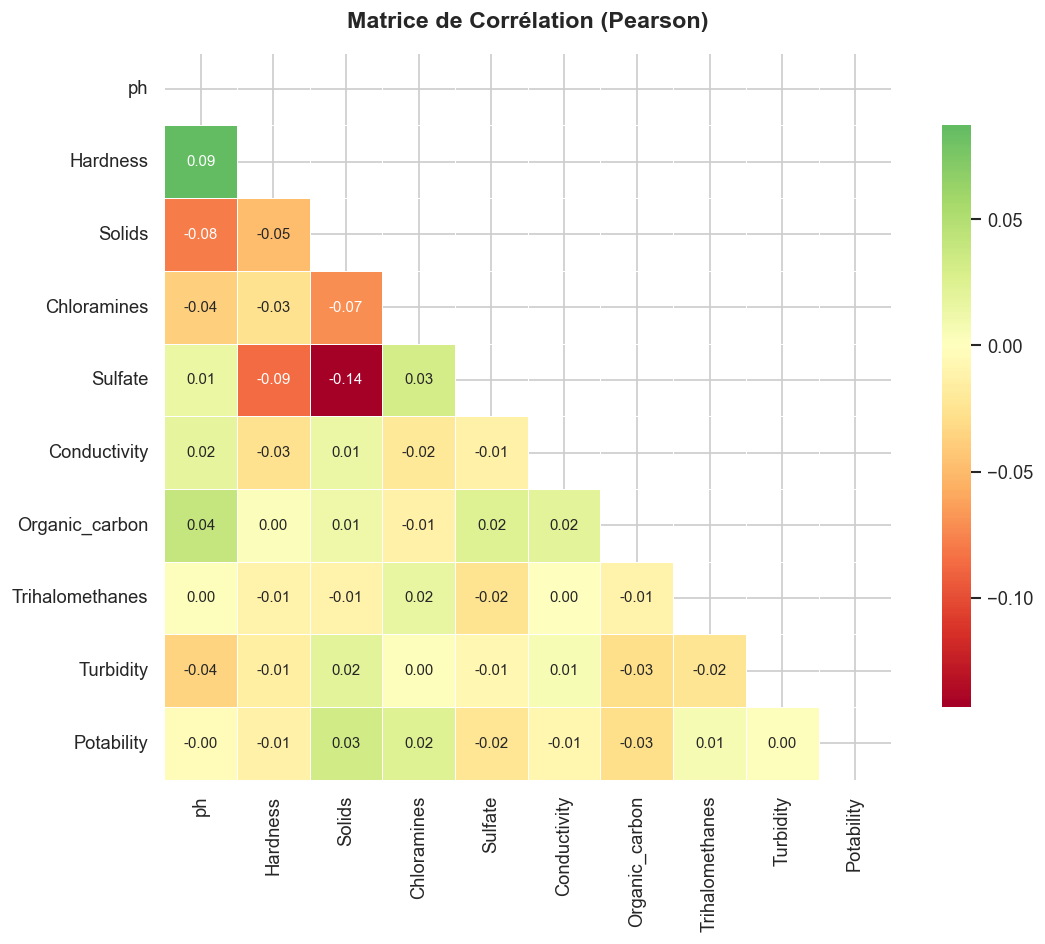


Corrélations avec Potabilité (triées) :
Solids             0.0329
Organic_carbon     0.0282
Chloramines        0.0234
Sulfate            0.0234
Hardness           0.0136
Conductivity       0.0084
Trihalomethanes    0.0070
ph                 0.0020
Turbidity          0.0018
Name: Potability, dtype: float64


In [14]:
# --- 4.3 Matrice de corrélation ---
corr = df_clean[features + ['Potability']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matrice de Corrélation (Pearson)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Top corrélations avec Potabilité
print('\nCorrélations avec Potabilité (triées) :')
print(corr['Potability'].drop('Potability').abs().sort_values(ascending=False).round(4))

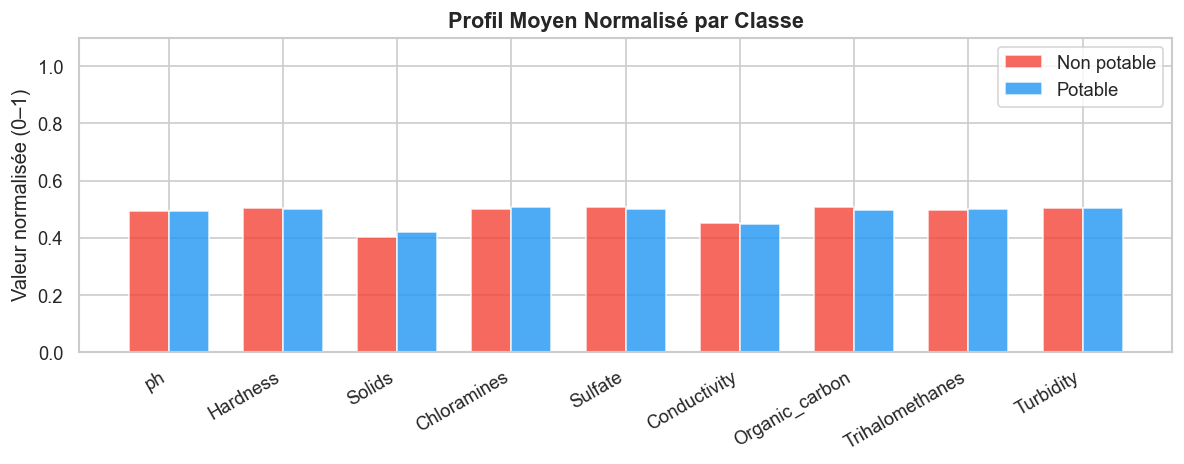

In [15]:
# --- 4.4 Moyennes par classe (radar normalisé) ---
from matplotlib.patches import FancyArrowPatch

group_means = df_clean.groupby('Potability')[features].mean()
normalized = (group_means - df_clean[features].min()) / \
             (df_clean[features].max() - df_clean[features].min())

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(features))
width = 0.35
ax.bar(x - width/2, normalized.loc[0], width, label='Non potable',
       color=COLORS['non_potable'], alpha=0.8, edgecolor='white')
ax.bar(x + width/2, normalized.loc[1], width, label='Potable',
       color=COLORS['potable'], alpha=0.8, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_ylabel('Valeur normalisée (0–1)')
ax.set_title('Profil Moyen Normalisé par Classe', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

Top 4 variables les plus corrélées à Potabilité : ['Solids', 'Organic_carbon', 'Chloramines', 'Sulfate']


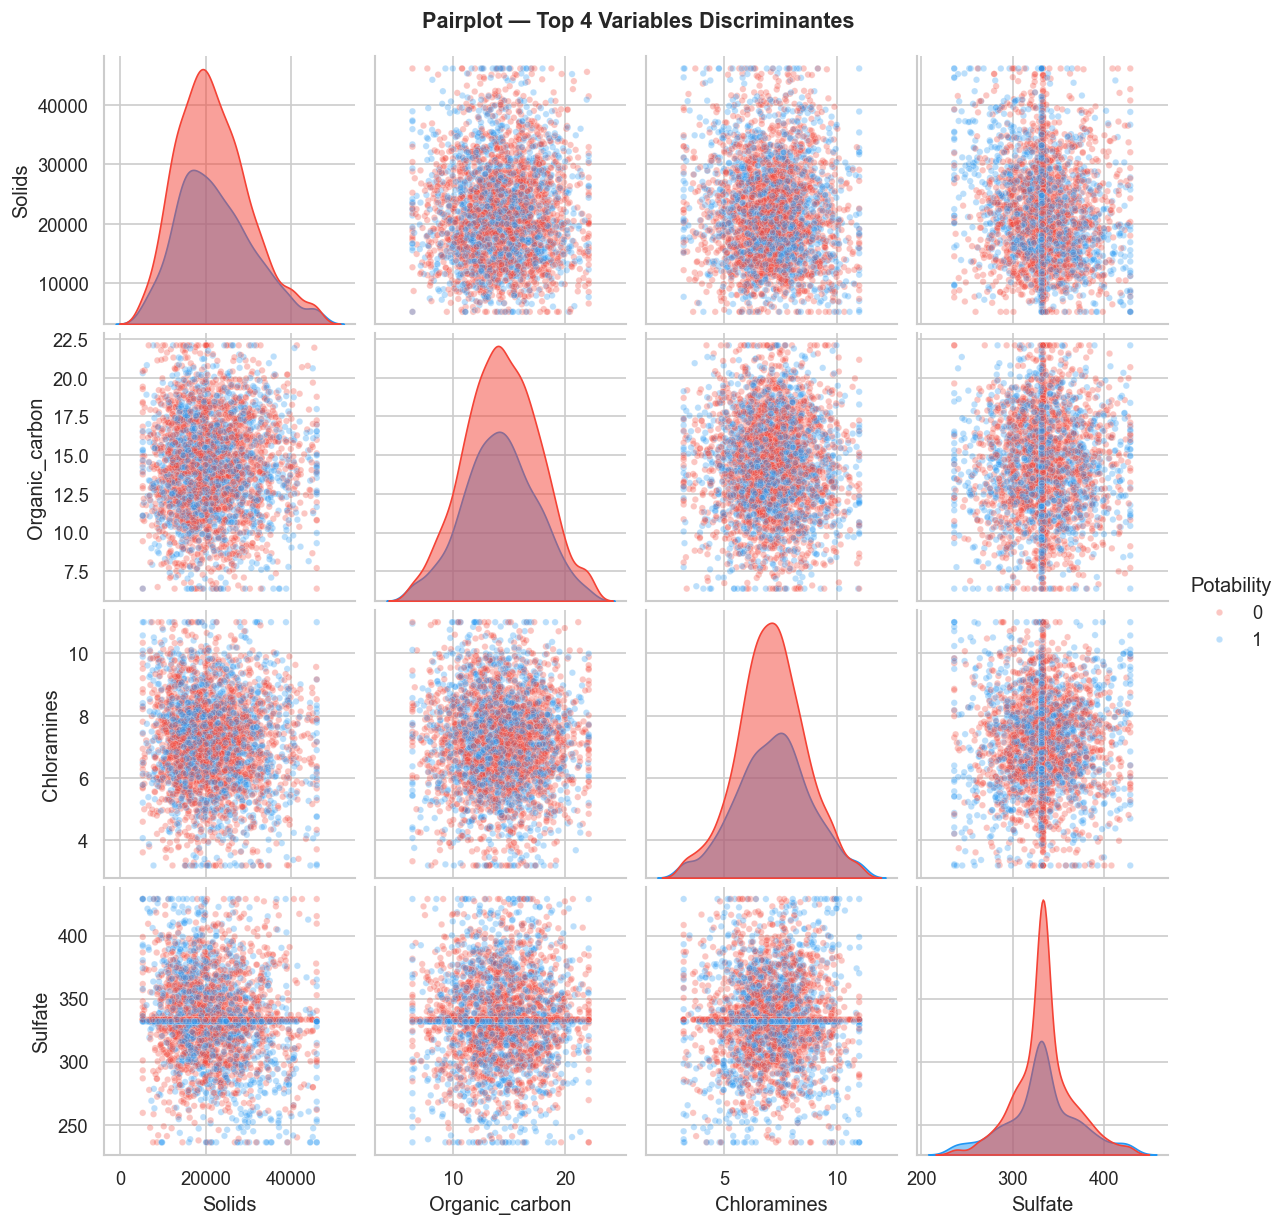

In [16]:
# --- 4.5 Pairplot des variables les plus discriminantes ---
top_vars = corr['Potability'].drop('Potability').abs().sort_values(ascending=False).head(4).index.tolist()
print(f'Top 4 variables les plus corrélées à Potabilité : {top_vars}')

g = sns.pairplot(df_clean[top_vars + ['Potability']], hue='Potability',
                 palette={0: COLORS['non_potable'], 1: COLORS['potable']},
                 diag_kind='kde', plot_kws={'alpha': 0.3, 's': 15},
                 diag_kws={'fill': True, 'alpha': 0.5})
g.fig.suptitle('Pairplot — Top 4 Variables Discriminantes', y=1.02, fontsize=13, fontweight='bold')
plt.show()

---
## 5. Export du Dataset Nettoyé

In [17]:
df_clean.to_csv('water_potability_clean.csv', index=False)
print(f'Dataset nettoyé sauvegardé : water_potability_clean.csv')
print(f'   Dimensions : {df_clean.shape}')
print(f'   Valeurs manquantes : {df_clean.isnull().sum().sum()}')

print('\n=== Résumé du Pré-traitement ===')
steps = [
    '1. Suppression des doublons',
    '2. Imputation par médiane conditionnelle (ph, Sulfate, Trihalomethanes)',
    '3. Winsorisation 1%-99% pour atténuer les valeurs aberrantes',
]
for s in steps:
    print(f'   {s}')

Dataset nettoyé sauvegardé : water_potability_clean.csv
   Dimensions : (3276, 10)
   Valeurs manquantes : 0

=== Résumé du Pré-traitement ===
   1. Suppression des doublons
   2. Imputation par médiane conditionnelle (ph, Sulfate, Trihalomethanes)
   3. Winsorisation 1%-99% pour atténuer les valeurs aberrantes


---
## 6. Conclusions

###  Données
- **3 276 échantillons**, 9 features physico-chimiques + 1 cible (`Potability`)
- **Déséquilibre** : 61% non potable, 39% potable → à considérer lors de la modélisation (SMOTE, class_weight)
- **Valeurs manquantes** : `ph` (15%), `Sulfate` (24%), `Trihalomethanes` (5%) → imputées par médiane par groupe

###  Observations Clés
- Aucune variable n'est fortement corrélée à `Potability` (max ~0.05) → problème difficile, non-linéaire
- Les distributions sont globalement similaires entre classes → les différences sont subtiles
- `Sulfate`, `ph` et `Conductivity` montrent les tendances les plus marquées selon les tests de Mann-Whitney

###  Recommandations pour la Modélisation
| Étape | Recommandation |
|-------|---------------|
| Rééchantillonnage | SMOTE ou class_weight='balanced' |
| Scaling | StandardScaler ou RobustScaler (après winsorisation) |
| Modèles | Random Forest, XGBoost, SVM |
| Métrique | F1-score, AUC-ROC (éviter l'accuracy seule) |
| Sélection de features | Importance des features + SHAP |